# Notebook 02: MLP Experiments

## Objectives
1. **Baseline MLP**: Train a 3-layer MLP [1024 → 512 → 256 → 10] on flattened CIFAR-10 images.
2. **Capacity Study**: Test how accuracy changes as we vary the number of hidden layers and neurons.
3. **Pixel Shuffling**: Randomly permute pixels and retrain to show MLPs treat images as unordered vectors.
4. **Misclassified Analysis**: Visualize which images the MLP gets wrong.

## Key Concepts
- **MLP Baseline**: Flattens 32×32×3 images into 3072-element vectors and learns fully connected mappings.
- **Dropout**: Used to prevent overfitting (0.3 rate).
- **Capacity**: More layers/neurons may help learning, but also increase overfitting risk.
- **Pixel Invariance**: MLPs are indifferent to pixel order—shuffling should NOT hurt performance much.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/cifar10-mlp-vs-cnn/notebooks')

os.makedirs('../results/figures', exist_ok=True)

metrics_path = '../results/metrics.json'

[MLP-Baseline] Epoch 01/20 | Loss: 1.7747 | Train Acc: 36.46% | Val Acc: 45.02%
[MLP-Baseline] Epoch 05/20 | Loss: 1.4451 | Train Acc: 49.13% | Val Acc: 48.40%
[MLP-Baseline] Epoch 10/20 | Loss: 1.2252 | Train Acc: 56.27% | Val Acc: 54.18%
[MLP-Baseline] Epoch 15/20 | Loss: 0.9716 | Train Acc: 64.96% | Val Acc: 57.44%
[MLP-Baseline] Epoch 20/20 | Loss: 0.8099 | Train Acc: 70.79% | Val Acc: 58.02%
MLP baseline test accuracy: 57.40%
[1L-64] Epoch 01/20 | Loss: 1.7982 | Train Acc: 36.60% | Val Acc: 44.16%
[1L-64] Epoch 05/20 | Loss: 1.5434 | Train Acc: 45.51% | Val Acc: 49.12%
[1L-64] Epoch 10/20 | Loss: 1.4408 | Train Acc: 49.46% | Val Acc: 50.36%
[1L-64] Epoch 15/20 | Loss: 1.3731 | Train Acc: 51.79% | Val Acc: 51.56%
[1L-64] Epoch 20/20 | Loss: 1.3324 | Train Acc: 53.20% | Val Acc: 51.62%
[1L-256] Epoch 01/20 | Loss: 1.7302 | Train Acc: 39.25% | Val Acc: 43.88%
[1L-256] Epoch 05/20 | Loss: 1.4139 | Train Acc: 50.61% | Val Acc: 50.30%
[1L-256] Epoch 10/20 | Loss: 1.2439 | Train Acc: 56.

NameError: name 'metrics' is not defined

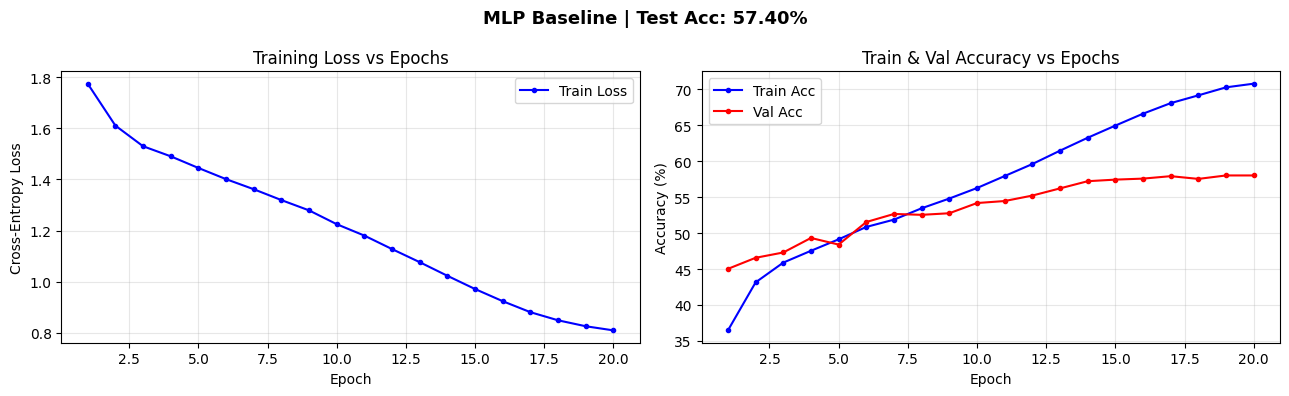

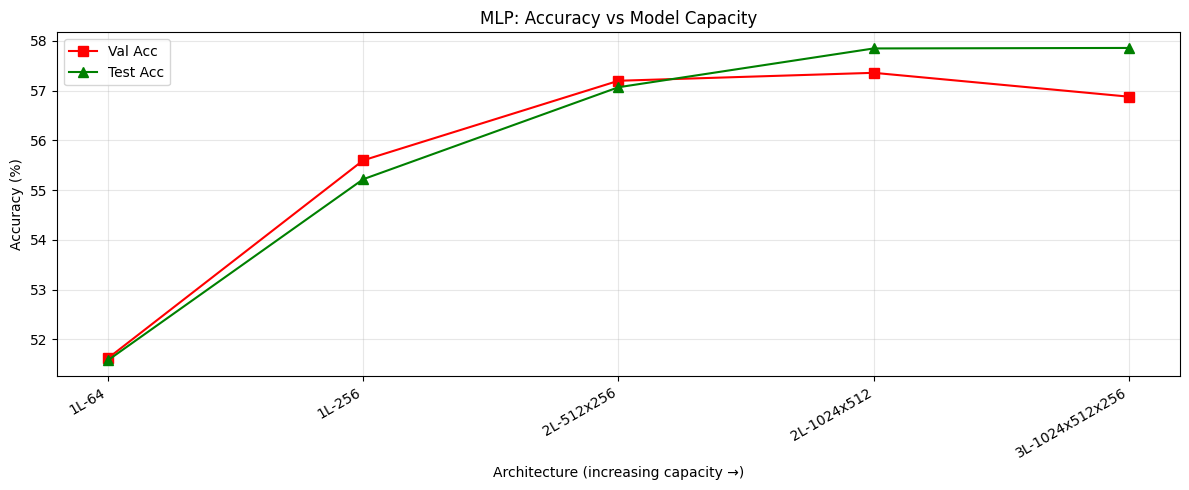

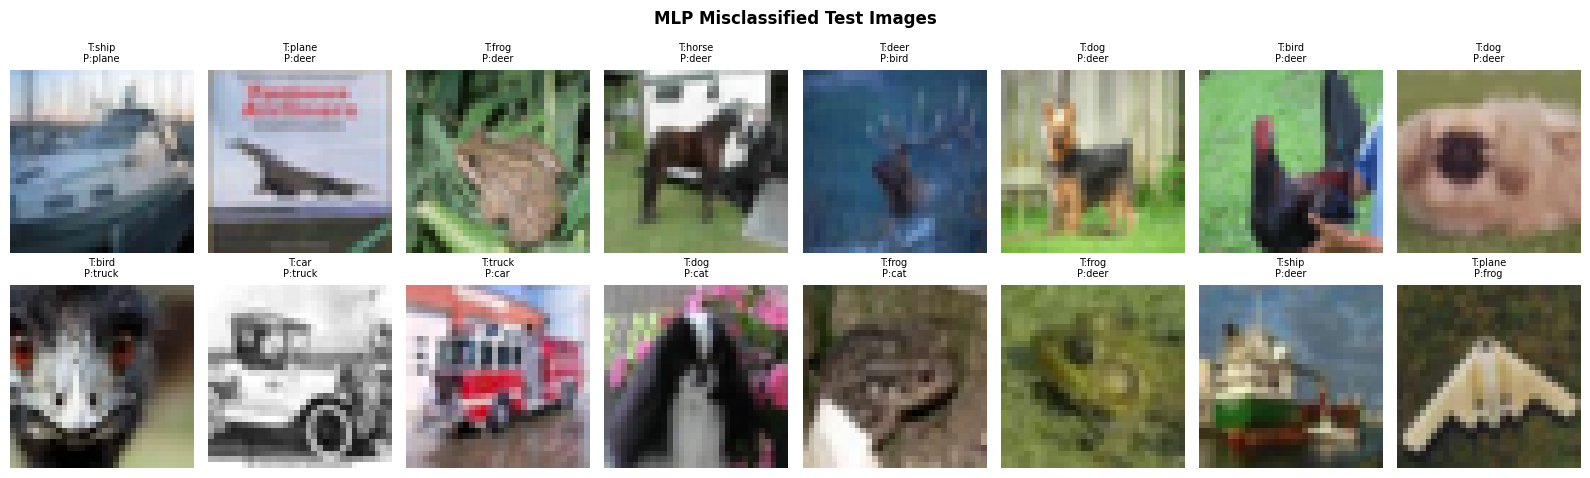

In [ ]:
from pathlib import Path
import json
import sys
import torch

sys.path.append(str(Path.cwd().parent / 'src'))

from data import get_dataloaders, ShuffleDataset
from models import MLP
from train import train_model, evaluate, count_parameters, get_misclassified
from visualize import plot_history, plot_capacity_results, visualize_misclassified

trainloader, valloader, testloader, trainset, valset, testset = get_dataloaders()
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

mlp_model = MLP(hidden_sizes=[1024, 512, 256], dropout=0.3)
mlp_history = train_model(mlp_model, trainloader, valloader, epochs=20, label='MLP-Baseline')
mlp_test_acc = evaluate(mlp_model, testloader)
print(f'MLP baseline test accuracy: {mlp_test_acc:.2f}%')
plot_history(mlp_history, title=f'MLP Baseline | Test Acc: {mlp_test_acc:.2f}%', save_path='../results/figures/mlp_training_curves.png')

capacity_configs = [
    {'hidden': [64], 'label': '1L-64'},
    {'hidden': [256], 'label': '1L-256'},
    {'hidden': [512, 256], 'label': '2L-512x256'},
    {'hidden': [1024, 512], 'label': '2L-1024x512'},
    {'hidden': [1024, 512, 256], 'label': '3L-1024x512x256'},
    # missing: {'hidden': [2048, 1024, 512, 256], 'label': '4L-2048x..'}
]
capacity_results = []
for cfg in capacity_configs:
    model = MLP(hidden_sizes=cfg['hidden'], dropout=0.3)
    history = train_model(model, trainloader, valloader, epochs=20, label=cfg['label'])
    test_acc = evaluate(model, testloader)
    capacity_results.append({'label': cfg['label'], 'params': count_parameters(model), 'train_acc': history['train_acc'][-1], 'val_acc': history['val_acc'][-1], 'test_acc': test_acc})
plot_capacity_results(capacity_results, save_path='../results/figures/mlp_capacity.png')

perm = torch.randperm(3072)

sh_train_ds = ShuffleDataset(trainloader.dataset, perm)   # the actual 90% train split
sh_val_ds   = ShuffleDataset(valloader.dataset, perm)      # the actual 10% val split
sh_test_ds  = ShuffleDataset(testset, perm)

sh_trainloader = torch.utils.data.DataLoader(sh_train_ds, batch_size=128, shuffle=True, num_workers=2)
sh_valloader   = torch.utils.data.DataLoader(sh_val_ds, batch_size=128, shuffle=False, num_workers=2)
sh_testloader  = torch.utils.data.DataLoader(sh_test_ds, batch_size=128, shuffle=False, num_workers=2)

shuffled_mlp = MLP(hidden_sizes=[1024, 512, 256], dropout=0.3)
shuffled_history = train_model(shuffled_mlp, sh_trainloader, sh_valloader, epochs=20, label='MLP-Shuffled')
shuffled_test_acc = evaluate(shuffled_mlp, sh_testloader)
print(f'Shuffled MLP test accuracy: {shuffled_test_acc:.2f}%')

mis_imgs, mis_true, mis_pred = get_misclassified(mlp_model, testloader, n=16)
visualize_misclassified(mis_imgs, mis_true, mis_pred, classes, title='MLP Misclassified Test Images', save_path='../results/figures/mlp_misclassified.png')

In [ ]:
import os
import json

metrics_path = '../results/metrics.json'

metrics = {}
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)

metrics.update({
    'mlp_test_accuracy': round(float(mlp_test_acc), 2),
    'mlp_shuffled_test_accuracy': round(float(shuffled_test_acc), 2),
    'capacity_results': capacity_results,
})

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved MLP metrics to ../results/metrics.json')

Saved MLP metrics to ../results/metrics.json


In [ ]:
torch.save(mlp_model.state_dict(), '../results/mlp_model.pt')

### Baseline MLP — Results

The 3-layer MLP (1024 → 512 → 256 → 10, dropout 0.3) achieves **57.40% test accuracy**
with 3.8M trainable parameters. Training accuracy climbs to 70.79% by epoch 20 while
validation accuracy plateaus around 58%, showing a ~13-point train/val gap — clear
evidence of overfitting despite dropout regularization. This relatively modest ceiling
(under 60%) reflects a fundamental limitation of MLPs on image data: flattening discards
all spatial structure, forcing the model to learn pixel-to-class mappings without any
built-in notion of locality or translation.

### Capacity Study — Analysis

| Architecture | Params | Train Acc | Val Acc | Test Acc |
|---|---|---|---|---|
| 1L-64 | 197,322 | 53.20% | 51.62% | 51.58% |
| 1L-256 | 789,258 | 65.33% | 55.60% | 55.22% |
| 2L-512x256 | 1,707,274 | 67.74% | 57.20% | 57.07% |
| 2L-1024x512 | 3,676,682 | 73.15% | 57.36% | 57.85% |
| 3L-1024x512x256 | 3,805,450 | 70.59% | 56.88% | 57.86% |


**Underfitting**: `1L-64`, with only ~197K parameters — roughly 19× smaller than the
largest config — has both the lowest training accuracy (53.20%) and the lowest test
accuracy (51.58%). The model simply lacks the capacity to fit the training data well,
let alone generalize.

**Diminishing returns**: Test accuracy improves steadily from `1L-64` through
`2L-1024x512` (51.58% → 57.85%), but `3L-1024x512x256` — despite having ~130K *more*
parameters than `2L-1024x512` — produces essentially the same test accuracy (57.86%
vs 57.85%) while its training accuracy is actually *lower* (70.59% vs 73.15%). Adding
a third hidden layer here doesn't translate into additional useful capacity; it mainly
changes the optimization dynamics without improving generalization.

**Overfitting signal**: From `2L-512x256` onward, every configuration shows a 10+ point
gap between training and validation/test accuracy (e.g. `2L-1024x512`: 73.15% train vs
57.85% test). This gap widens as capacity increases, indicating the larger models are
increasingly memorizing training examples rather than learning transferable features —
classic overfitting behavior that plateaus test performance around 57-58% regardless
of how much capacity is added beyond `2L-512x256`.

**Practical takeaway**: For this architecture family on CIFAR-10, `2L-1024x512` offers
the best accuracy-per-parameter trade-off — comparable test accuracy to the larger
`3L-1024x512x256` config at ~130K fewer parameters and noticeably less overfitting.

### Pixel Shuffling — Analysis

Applying a single fixed permutation to every image (consistently across train and test)
and retraining gives **57.42% test accuracy** — virtually identical to the baseline's
57.40%, despite every image's pixels being scrambled into the same fixed, but spatially
meaningless, order.

This confirms MLPs are **permutation invariant** with respect to their input: since the
image is flattened into a 1D vector before any computation happens, the model has no
notion of which pixels were originally adjacent. It simply learns a fixed mapping from
each of the 3072 input positions to the output classes — as long as that mapping is
applied consistently, scrambling which physical pixel occupies which position doesn't
matter. This is precisely why MLPs lack the *spatial inductive bias* that makes CNNs
so much more effective for image data: a CNN's accuracy collapses under similar pixel
shuffling, because its convolutional filters depend on genuine spatial locality.

### Misclassified Images

The MLP's errors are concentrated among visually similar or texturally ambiguous classes
(e.g. cat/dog, deer/horse, automobile/truck) — consistent with a model that has learned
coarse color/texture statistics rather than structural object features, a natural
consequence of discarding spatial information entirely.